In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.lines as mlines


PROJECT_ROOT = Path("/Users/ydnkka/Desktop/PhD Project/projects/scotland")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from utils import window_policy_lookup, lineage_clade_lookup, policy_era_labels  # noqa: E402
from utils import new_figure  # noqa: E402

In [2]:
ass_raw = pd.read_parquet(
    PROJECT_ROOT
    / "chapter_analyses/genomic_networks/results/tables/compatibility_assortativity_bootstrap.parquet"
)

In [3]:
windows = window_policy_lookup(ass_raw["window_id"].unique())
variants = lineage_clade_lookup(ass_raw["window_id"].unique(), display_labels=True)
ass_raw = (
    ass_raw.merge(windows, on="window_id", how="left")
    .merge(variants, on="pango_lineage", how="left")
)
ass = ass_raw.dropna(subset=["assortativity"])
ass = ass[ass["n_edges_used"] >= 35].copy()
ass["epoch_label"] = ass["policy_era"].map(policy_era_labels())

In [4]:
len(ass_raw), len(ass)

(38416, 15561)

In [5]:
ass.columns

Index(['attribute', 'attribute_label', 'window_id', 'pango_lineage',
       'n_edges_observed', 'n_edges_used', 'edge_weight_total', 'n_categories',
       'assortativity', 'observed_same_category_weight',
       'expected_same_category_weight', 'uncertainty_method',
       'bootstrap_replicates', 'bootstrap_finite_replicates',
       'assortativity_se', 'assortativity_ci_low', 'assortativity_ci_high',
       'skipped_reason', 'pairwise_stem', 'window_idx', 'wn_mid_date',
       'stringency_index', 'containment_index', 'policy_period',
       'policy_period_label', 'policy_period_start_date',
       'policy_period_end_date', 'policy_period_order', 'policy_era', 'clade',
       'clade_label', 'epoch_label'],
      dtype='str')

In [13]:
# ---------- tau^2 estimators ----------


def _weighted_mean(y, v, tau2):
    w = 1.0 / (v + tau2)
    return np.sum(w * y) / np.sum(w), w


def _tau2_DL(y, v):
    """DerSimonian-Laird (closed form)."""
    w = 1.0 / v
    sw = w.sum()
    mu = np.sum(w * y) / sw
    q = np.sum(w * (y - mu) ** 2)
    df = len(y) - 1
    c = sw - np.sum(w**2) / sw
    return max(0.0, (q - df) / c) if c > 0 else 0.0


def _tau2_PM(y, v, tol=1e-8, max_iter=200):
    """
    Paule-Mandel: find tau2 s.t. sum w_i (y_i - mu)^2 = k - 1,
    with w_i = 1/(v_i + tau2). Solved by bisection (F is monotone
    decreasing in tau2).
    """
    df = len(y) - 1

    def F(tau2):
        mu, w = _weighted_mean(y, v, tau2)
        return np.sum(w * (y - mu) ** 2) - df

    # if even tau2=0 gives F<=0, there is no positive root
    if F(0.0) <= 0:
        return 0.0

    lo, hi = 0.0, max(v.max(), 1.0)
    # expand upper bound until F(hi) < 0
    it = 0
    while F(hi) > 0 and it < 60:
        hi *= 2.0
        it += 1

    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        f = F(mid)
        if abs(f) < tol or (hi - lo) < tol:
            return max(0.0, mid)
        if f > 0:
            lo = mid
        else:
            hi = mid
    return max(0.0, 0.5 * (lo + hi))


def _tau2_REML(y, v, tol=1e-8, max_iter=500):
    """REML via fixed-point iteration (Viechtbauer 2005)."""
    tau2 = max(_tau2_DL(y, v), 0.0)  # warm start
    for _ in range(max_iter):
        w = 1.0 / (v + tau2)
        sw = w.sum()
        mu = np.sum(w * y) / sw
        # REML update
        num = np.sum(w**2 * ((y - mu) ** 2 - v)) + (1.0 / sw)
        den = np.sum(w**2)
        tau2_new = max(0.0, num / den)
        if abs(tau2_new - tau2) < tol:
            tau2 = tau2_new
            break
        tau2 = tau2_new
    return tau2


_TAU2_ESTIMATORS = {"DL": _tau2_DL, "PM": _tau2_PM, "REML": _tau2_REML}


# ---------- main pooling function ----------


def random_effects_pool(
    data,
    est_col="assortativity",
    se_col="assortativity_se",
    method="REML",  # "DL", "PM", or "REML"
    bounds=(-1.0, 1.0),  # set to None to disable clipping
    use_hksj=True,  # Hartung-Knapp-Sidik-Jonkman small-sample CI
    conf_level=0.95,
):
    """
    Random-effects meta-analysis with selectable tau^2 estimator,
    HKSJ small-sample CIs, and a prediction interval.
    Returns a one-row DataFrame (stable across pandas versions).
    """
    if method not in _TAU2_ESTIMATORS:
        raise ValueError(f"method must be one of {list(_TAU2_ESTIMATORS)}")

    cols = [
        "n_lineages",
        "method",
        "pooled_mean",
        "pooled_se",
        "pooled_ci_low",
        "pooled_ci_high",
        "tau2",
        "i2",
        "q",
        "q_pvalue",
        "pred_int_low",
        "pred_int_high",
        "q05",
        "q25",
        "median",
        "q75",
        "q95",
    ]

    def empty(k):
        out = {c: np.nan for c in cols}
        out["n_lineages"] = k
        out["method"] = method
        return pd.DataFrame([out])[cols]

    # ---- clean input ----
    d = data[[est_col, se_col]].copy()
    d = d.replace([np.inf, -np.inf], np.nan).dropna()
    d = d[d[se_col] > 0]

    k = len(d)
    if k < 2:
        return empty(k)

    y = d[est_col].to_numpy(dtype=float)
    se = d[se_col].to_numpy(dtype=float)
    v = se**2
    alpha = 1.0 - conf_level

    # ---- heterogeneity (Q always via fixed-effect weights) ----
    w_fe = 1.0 / v
    mu_fixed = np.sum(w_fe * y) / w_fe.sum()
    q = np.sum(w_fe * (y - mu_fixed) ** 2)
    df_q = k - 1
    q_pvalue = stats.chi2.sf(q, df_q)
    i2 = max(0.0, (q - df_q) / q) if q > 0 else 0.0

    # ---- tau^2 via chosen estimator ----
    tau2 = _TAU2_ESTIMATORS[method](y, v)

    # ---- random-effects estimate ----
    w_re = 1.0 / (v + tau2)
    sw_re = w_re.sum()
    pooled_mean = np.sum(w_re * y) / sw_re
    var_wald = 1.0 / sw_re

    # ---- confidence interval ----
    if use_hksj and k >= 2:
        q_hk = np.sum(w_re * (y - pooled_mean) ** 2) / df_q
        var_ci = max(q_hk / sw_re, var_wald)  # guard against over-precision
        crit = stats.t.ppf(1 - alpha / 2, df=df_q)
    else:
        var_ci = var_wald
        crit = stats.norm.ppf(1 - alpha / 2)

    pooled_se = np.sqrt(var_ci)
    ci_low = pooled_mean - crit * pooled_se
    ci_high = pooled_mean + crit * pooled_se

    # ---- prediction interval (needs k >= 3) ----
    if k >= 3:
        t_pred = stats.t.ppf(1 - alpha / 2, df=k - 2)
        pred_se = np.sqrt(tau2 + var_wald)
        pred_low = pooled_mean - t_pred * pred_se
        pred_high = pooled_mean + t_pred * pred_se
    else:
        pred_low = pred_high = np.nan

    # ---- optional clipping ----
    if bounds is not None:
        lo, hi = bounds
        ci_low, ci_high = max(lo, ci_low), min(hi, ci_high)
        if np.isfinite(pred_low):
            pred_low = max(lo, pred_low)
        if np.isfinite(pred_high):
            pred_high = min(hi, pred_high)

    out = {
        "n_lineages": k,
        "method": method,
        "pooled_mean": pooled_mean,
        "pooled_se": pooled_se,
        "pooled_ci_low": ci_low,
        "pooled_ci_high": ci_high,
        "tau2": tau2,
        "i2": i2,
        "q": q,
        "q_pvalue": q_pvalue,
        "pred_int_low": pred_low,
        "pred_int_high": pred_high,
        "q05": np.quantile(y, 0.05),
        "q25": np.quantile(y, 0.25),
        "median": np.median(y),
        "q75": np.quantile(y, 0.75),
        "q95": np.quantile(y, 0.95),
    }
    return pd.DataFrame([out])[cols]


# ---- apply across groups (version-stable) ----
group_keys = ["attribute", "attribute_label", "window_idx"]

window_meta = (
    ass.groupby(group_keys, observed=True)
    .apply(random_effects_pool, method="REML")
    .reset_index(level=-1, drop=True)
    .reset_index()
)

In [14]:
print(window_meta.groupby("attribute_label")[["pooled_mean", "pooled_ci_low", "pooled_ci_high"]].mean().to_string())

                   pooled_mean  pooled_ci_low  pooled_ci_high
attribute_label                                              
Age band             -0.010138      -0.073478        0.053201
Age group             0.012189      -0.087402        0.111548
Health board          0.267023       0.081111        0.429264
Local authority       0.168531       0.035600        0.296444
SIMD quintile         0.007477      -0.058860        0.075779
Sex                  -0.014507      -0.067229        0.038216
Urban/rural class     0.079476      -0.018271        0.174817


In [15]:
def plot_pooled_window_meta(meta, x_col="window_idx", exclude_attrs=None):
    if exclude_attrs is None:
        exclude_attrs = []

    if "pooled_ci_low" not in meta.columns and {"level_3", 0}.issubset(meta.columns):
        meta = meta.pivot_table(
            index=["attribute", "attribute_label", x_col],
            columns="level_3",
            values=0,
            aggfunc="first",
        ).reset_index()

    attributes = meta["attribute_label"].dropna().unique()
    attributes = [attr for attr in attributes if attr not in exclude_attrs]

    n_attrs = len(attributes)
    ncols = 3
    nrows = int(np.ceil(n_attrs / ncols))

    fig, axes = new_figure(
        nrows=nrows, ncols=ncols, width="double", height_in=6, sharex=True, sharey=True
    )

    axes = np.array(axes).reshape(-1)

    for ax, attr in zip(axes, attributes):
        d = meta[meta["attribute_label"] == attr].sort_values(x_col)

        x = d[x_col].to_numpy()

        # Bootstrap/SE-informed CI for pooled mean
        ax.fill_between(
            x,
            d["pooled_ci_low"].to_numpy(),
            d["pooled_ci_high"].to_numpy(),
            alpha=0.25,
            color="#4C72B0",
            label="95% CI for pooled mean",
        )

        ax.plot(
            x,
            d["pooled_mean"].to_numpy(),
            color="#4C72B0",
            linewidth=2,
            label="Random-effects pooled mean",
        )

        # Between-lineage IQR
        ax.fill_between(
            x,
            d["q25"].to_numpy(),
            d["q75"].to_numpy(),
            alpha=0.20,
            color="#DD8452",
            label="Between-lineage IQR",
        )

        ax.plot(
            x,
            d["median"].to_numpy(),
            color="#DD8452",
            linewidth=1.5,
            linestyle="--",
            label="Median across lineages",
        )

        ax.axhline(0, color="black", linestyle="--", linewidth=1)

        ax.set_title(str(attr))

    for ax in axes[len(attributes) :]:
        ax.remove()

    fig.supylabel("Assortativity")
    fig.supxlabel("Window")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=2)

    fig.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()

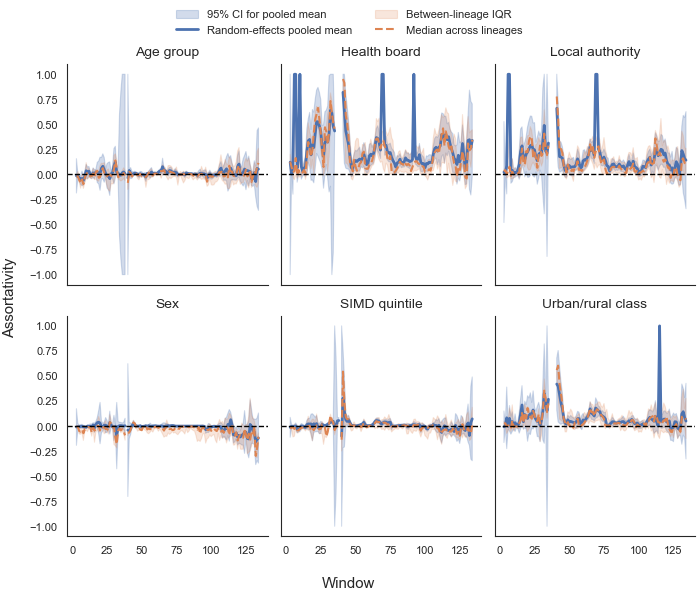

In [16]:
plot_pooled_window_meta(window_meta, exclude_attrs=["Age band"])

In [17]:
import statsmodels.formula.api as smf


def variance_decomposition_additive_model(
    data,
    min_rows=5,
    group_keys=("window_id", "pango_lineage"),
    winsorize_weights=None,
):
    """
    Weighted (inverse-variance) variance decomposition of `assortativity`
    across `group_keys`.

    Uses WLS with weights = 1 / SE^2 so noisy estimates are down-weighted.
    Reports both conditional orderings because sequential sums of squares
    are order-dependent for unbalanced/confounded designs.

    Parameters
    ----------
    data : pd.DataFrame
        Must contain `group_keys`, `assortativity`, and `assortativity_se`.
    min_rows : int
        Minimum number of clean rows required to attempt the decomposition.
    group_keys : tuple[str, str]
        Exactly two categorical factor columns to decompose variance over.
    winsorize_weights : float or None
        If set (e.g. 99), cap inverse-variance weights at this upper
        percentile to stop a few tiny-SE points dominating the fit.
        `None` disables winsorising.
    """
    if len(group_keys) != 2:
        raise ValueError(f"group_keys must contain exactly 2 columns, got {group_keys}")

    k0, k1 = group_keys

    # --- Select columns, keeping ci_width only if present -----------------
    base_cols = list(group_keys) + ["assortativity", "assortativity_se"]
    missing = [c for c in base_cols if c not in data.columns]
    if missing:
        raise KeyError(f"Missing required columns: {missing}")

    cols = base_cols + (["ci_width"] if "ci_width" in data.columns else [])
    d = data[cols].copy()

    # --- Clean: require finite values and strictly positive SE ------------
    d = d.dropna(subset=base_cols)
    d["assortativity"] = d["assortativity"].astype(float)
    d["assortativity_se"] = d["assortativity_se"].astype(float)
    d = d[
        np.isfinite(d["assortativity"])
        & np.isfinite(d["assortativity_se"])
        & (d["assortativity_se"] > 0)
    ]

    if len(d) < min_rows:
        return pd.Series(dtype=float)

    # --- Factors ----------------------------------------------------------
    d[k0] = d[k0].astype("category")
    d[k1] = d[k1].astype("category")

    n = len(d)
    n_windows = d[k0].nunique()
    n_lineages = d[k1].nunique()

    # Need >1 level in each factor for the decomposition to be meaningful
    if n_windows < 2 or n_lineages < 2:
        return pd.Series(dtype=float)

    # --- Inverse-variance weights (optionally winsorised) -----------------
    w = 1.0 / d["assortativity_se"] ** 2
    weight_cap = np.nan
    n_weights_capped = 0
    if winsorize_weights is not None:
        weight_cap = np.nanpercentile(w, winsorize_weights)
        n_weights_capped = int((w > weight_cap).sum())
        w = np.minimum(w, weight_cap)
    d["w"] = w

    # --- Fit nested WLS models (shared weights) ---------------------------
    def _fit(formula):
        return smf.wls(formula, data=d, weights=d["w"]).fit()

    m0 = _fit("assortativity ~ 1")
    m_window = _fit(f"assortativity ~ C({k0})")
    m_lineage = _fit(f"assortativity ~ C({k1})")
    m_both = _fit(f"assortativity ~ C({k0}) + C({k1})")

    ss_total = m0.ssr
    if not np.isfinite(ss_total) or ss_total <= 0:
        return pd.Series(dtype=float)

    # --- Sums of squares --------------------------------------------------
    window_alone = m0.ssr - m_window.ssr
    lineage_alone = m0.ssr - m_lineage.ssr
    additive_explained = m0.ssr - m_both.ssr

    lineage_given_window = m_window.ssr - m_both.ssr   # extra SS for k1 | k0
    window_given_lineage = m_lineage.ssr - m_both.ssr  # extra SS for k0 | k1
    residual = m_both.ssr

    # --- Degrees of freedom for adjusted fraction -------------------------
    df_model_both = m_both.df_model          # params - 1
    df_resid_both = m_both.df_resid
    # Adjusted R^2 style explained fraction (penalises many categories)
    if df_resid_both > 0:
        adj_additive_fraction = 1.0 - (residual / df_resid_both) / (
            ss_total / (n - 1)
        )
    else:
        adj_additive_fraction = np.nan

    return pd.Series(
        {
            "n": n,
            "n_windows": n_windows,
            "n_lineages": n_lineages,
            "df_model_additive": df_model_both,
            "df_resid_additive": df_resid_both,
            "weighted_total_ss": ss_total,
            # Single-factor (do NOT sum these; factors may be confounded)
            "window_alone_fraction": window_alone / ss_total,
            "lineage_alone_fraction": lineage_alone / ss_total,
            # Additive joint model
            "additive_model_fraction": additive_explained / ss_total,
            "adj_additive_model_fraction": adj_additive_fraction,
            "residual_fraction": residual / ss_total,
            # Order-dependent conditional (Type-I extra SS) contributions
            "lineage_given_window_fraction": lineage_given_window / ss_total,
            "window_given_lineage_fraction": window_given_lineage / ss_total,
            # Weight diagnostics
            "weight_cap": weight_cap,
            "n_weights_capped": n_weights_capped,
            # Diagnostics on the input uncertainties
            "median_boot_se": d["assortativity_se"].median(),
            "median_ci_width": (
                d["ci_width"].median() if "ci_width" in d.columns else np.nan
            ),
        }
    )

In [18]:
vd_results = {}
for w in list(range(0, 100, 5)) + [99]:
    print(f"winsorize_weights={w}")
    vd = (
        ass.groupby(["attribute", "attribute_label"], observed=True)
        .apply(variance_decomposition_additive_model, winsorize_weights=w)
        .reset_index()
    )
    vd["winsorize"] = w
    vd_results[w] = vd

vd_long = pd.concat(vd_results, ignore_index=True)

winsorize_weights=0
winsorize_weights=5
winsorize_weights=10
winsorize_weights=15
winsorize_weights=20
winsorize_weights=25
winsorize_weights=30
winsorize_weights=35
winsorize_weights=40
winsorize_weights=45
winsorize_weights=50
winsorize_weights=55
winsorize_weights=60
winsorize_weights=65
winsorize_weights=70
winsorize_weights=75
winsorize_weights=80
winsorize_weights=85
winsorize_weights=90
winsorize_weights=95
winsorize_weights=99


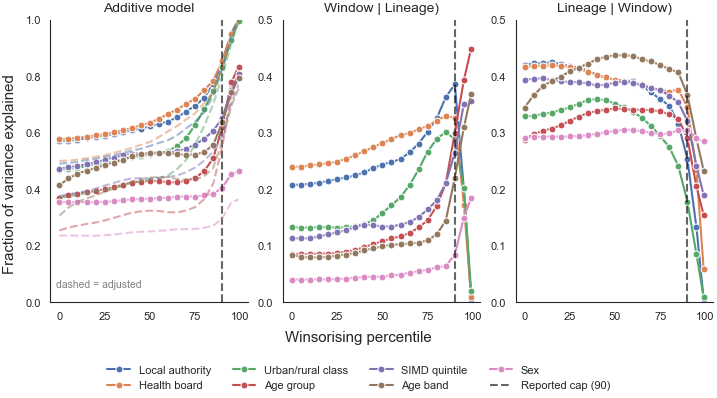

In [19]:
fig, axes = new_figure(
    nrows=1,
    ncols=3,
    width="double",
    height_in=3.5,
    constrained_layout=True,
    sharex=True,
)

order = vd_long[vd_long.winsorize == 95].sort_values(
    "additive_model_fraction", ascending=False
)["attribute_label"]

# (column, title, ylim) — one entry per panel
panels = [
    ("additive_model_fraction", "Additive model", (0, 1)),
    (
        "window_given_lineage_fraction",
        "Window | Lineage)",
        (0, 0.5),
    ),
    (
        "lineage_given_window_fraction",
        "Lineage | Window)",
        (0, 0.5),
    ),
]

for ax, (col, title, ylim) in zip(axes, panels):
    sns.lineplot(
        data=vd_long,
        x="winsorize",
        y=col,
        hue="attribute_label",
        hue_order=order,
        marker="o",
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_ylim(*ylim)
    ax.axvline(90, ls="--", color="black", alpha=0.6)

# Adjusted fraction overlay — panel 0 only
sns.lineplot(
    data=vd_long,
    x="winsorize",
    y="adj_additive_model_fraction",
    hue="attribute_label",
    hue_order=order,
    ls="--",
    alpha=0.5,
    ax=axes[0],
)
axes[0].set_xlabel("")
axes[0].set_ylabel("")

# --- Shared legend -------------------------------------------------------
# Grab handles from a single-line panel (axes[1]) to avoid solid/dashed dupes
handles, labels = axes[1].get_legend_handles_labels()

for ax in axes:
    ax.get_legend().remove()

# Add a proxy entry for the reported-cap vline
handles.append(mlines.Line2D([], [], ls="--", color="black", alpha=0.6))
labels.append("Reported cap (90)")

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    bbox_to_anchor=(0.5, -0.15),
)

axes[0].plot([], [], ls="--", color="k", alpha=0.5, label="_")
axes[0].text(
    0.03,
    0.05,
    "dashed = adjusted",
    transform=axes[0].transAxes,
    fontsize="small",
    color="grey",
)


fig.supxlabel("Winsorising percentile")
fig.supylabel("Fraction of variance explained");